In [2]:
import torch
import random
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

!curl -O https://raw.githubusercontent.com/karpathy/makemore/master/names.txt
words = open('names.txt', 'r').read().splitlines()


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  222k  100  222k    0     0  1414k      0 --:--:-- --:--:-- --:--:-- 1419k


In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)


In [4]:
def build_dataset(words):
  block_size = 8
  X, Y = [], []
  for w in words:
     context = [0] * block_size
     for ch in w + '.':
       ix= stoi[ch]
       X.append(context)
       Y.append(ix)
       context = context[1:] + [ix]
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


In [5]:
for x,y in zip(Xtr[:20], Ytr[:20]):
  print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> y
.......y --> u
......yu --> h
.....yuh --> e
....yuhe --> n
...yuhen --> g
..yuheng --> .
........ --> d
.......d --> i
......di --> o
.....dio --> n
....dion --> d
...diond --> r
..diondr --> e
.diondre --> .
........ --> x
.......x --> a
......xa --> v
.....xav --> i
....xavi --> e


In [1]:
class Linear:
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self,x):

    if self.training:
      if x.ndim == 2:
        dim = 0
      elif x.ndim == 3:
        dim = (0,1)
      xmean = x.mean(dim, keepdim=True)
      xvar = x.var(dim, keepdim=True)
#2 boyutlu girdide sadece batch ekseni, 3 boyutlu girdide hem batch hem zaman ekseni birlikte kullanılıyor.
#Sonuç karşılaştırması:
#Düzeltme öncesi: train 1.80, val 1.99
#Düzeltme sonrası: train 1.76, val 1.99
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x-xmean)/torch.sqrt(xvar + self.eps)
    self.out = self.gamma * xhat + self.beta

    if self.training:
      with torch.no_grad():
        self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
        self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar

    return self.out

  def parameters(self):
    return([self.gamma, self.beta])

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return[]

class Embedding:
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
  def __call__(self, x):
    self.out = self.weight[x]
    return self.out
  def parameters(self):
    return [self.weight]

class FlattenConsecutive:
  def __init__(self, n):
    self.n = n

  def __call__(self, x):
    B, T, C = x.shape
    x = x.view(B, T//self.n, C*self.n)
    if x.shape[1] == 1:
      x = x.squeeze(1)
    self.out = x
    return self.out
  def parameters(self):
    return []

class Sequential:
  def __init__(self, layers):
    self.layers = layers
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [6]:
torch.manual_seed(42);
block_size = 8
n_embd = 24
n_hidden = 300
C = torch.randn((vocab_size, n_embd))
model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd * 2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
  model.layers[-1].weight *= 0.1

parameters = model.parameters()
print(sum(p.nelement() for p in parameters))
for p in parameters:
  p.requires_grad = True

384975


In [7]:
model_flat = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(8), Linear(n_embd*8, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])
with torch.no_grad():
  model_flat.layers[-1].weight *= 0.1
parameters_flat = model_flat.parameters()
for p in parameters_flat:
  p.requires_grad = True
print(sum(p.nelement() for p in parameters_flat))

66975


In [8]:
for layer in model_flat.layers:
  if hasattr(layer, 'training'):
    layer.training = False

In [9]:
lossi_flat = []
max_steps = 200000
batch_size = 32
for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]
  logits = model_flat(Xb)
  loss = F.cross_entropy(logits, Yb)
  for p in parameters_flat:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 100000 else 0.01
  for p in parameters_flat:
    if p.grad is not None:
      p.data += -lr * p.grad

  if i % 10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi_flat.append(loss.log10().item())

      0/ 200000: 3.2852
  10000/ 200000: 1.9045
  20000/ 200000: 2.0009
  30000/ 200000: 2.1491
  40000/ 200000: 2.1823
  50000/ 200000: 1.7526
  60000/ 200000: 1.5021
  70000/ 200000: 2.3234
  80000/ 200000: 1.8323
  90000/ 200000: 2.6358
 100000/ 200000: 1.8526
 110000/ 200000: 1.7321
 120000/ 200000: 1.6600
 130000/ 200000: 1.4421
 140000/ 200000: 1.7272
 150000/ 200000: 1.8747
 160000/ 200000: 2.0114
 170000/ 200000: 1.6667
 180000/ 200000: 1.7730
 190000/ 200000: 1.3538


In [10]:
@torch.no_grad()
def split_loss_flat(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model_flat(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss_flat('train')
split_loss_flat('val')

train 1.7841899394989014
val 2.0432627201080322


In [11]:
ix = torch.randint(0, Xtr.shape[0], (32,))
Xb, Yb = Xtr[ix], Ytr[ix]
logits = model(Xb)
print(logits.shape)

torch.Size([32, 27])


In [12]:
lossi = []
for i in range(max_steps):
  ix = torch.randint(0, Xtr.shape[0], (batch_size,))
  Xb, Yb = Xtr[ix], Ytr[ix]
  x = Xb
  logits = model(Xb)
  loss = F.cross_entropy(logits, Yb)
  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    if p.grad is not None:
      p.data += -lr * p.grad

  if i %10000 == 0:
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())


      0/ 200000: 3.2963
  10000/ 200000: 2.2182
  20000/ 200000: 1.8820
  30000/ 200000: 1.9355
  40000/ 200000: 1.7297
  50000/ 200000: 2.2473
  60000/ 200000: 2.2781
  70000/ 200000: 1.5377
  80000/ 200000: 1.7077
  90000/ 200000: 1.8899
 100000/ 200000: 1.7096
 110000/ 200000: 1.3396
 120000/ 200000: 1.3762
 130000/ 200000: 1.7164
 140000/ 200000: 1.4855
 150000/ 200000: 1.8529
 160000/ 200000: 1.9930
 170000/ 200000: 2.0096
 180000/ 200000: 2.0366
 190000/ 200000: 1.6070


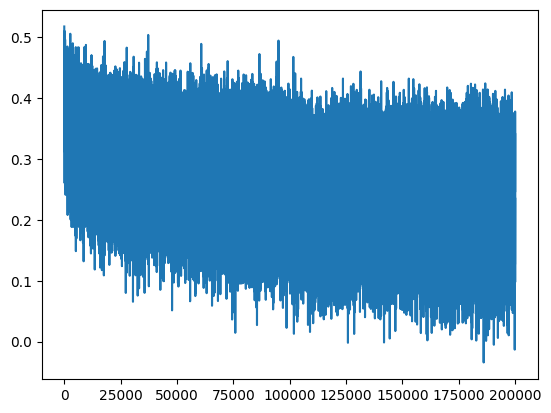

In [13]:
plt.plot(lossi) #ilk hali böyleydi.

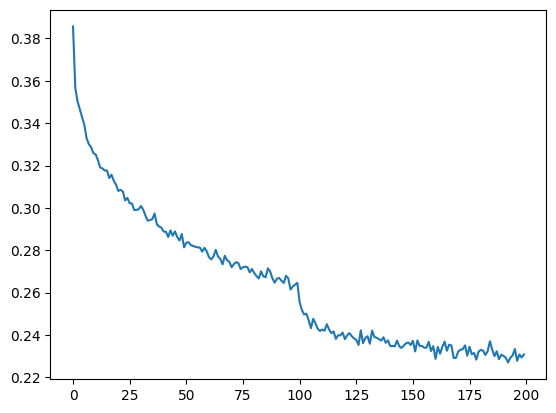

In [14]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))


In [15]:
for layer in model.layers:
  print(layer.__class__.__name__, ':', tuple(layer.out.shape))
#Embedding katmanı her harfi 24 boyutlu bir vektöre çeviriyor,
#İlk FlattenConsecutive(2) katmanı, art arda gelen 2 harfin embeddinglerini birleştiriyor
#T 8'den 4'e iniyor, C ise 24'ten 48'e (24×2) çıkıyor, yani (32, 4, 48)
#BatchNorm ve Tanh şekli değiştirmiyor, sadece normalize edip doğrusal olmayanlık ekliyor.
#İkinci FlattenConsecutive(2) katmanı, kalan 4 adım ikişer ikişer birleştirip 2'ye indiriyor bu yüzden 300'den 600'e çıkıyor yani (32, 2, 600)
#Üçüncü FlattenConsecutive(2) son iki zaman adımını da birleştirip T=1 yapıyor, kod bu durumda T eksenini squeeze ile kaldırıyor, böylece çıktı 2 boyutlu düz bir vektöre dönüşüyor:(32, 600)
#Son Linear katmanı bu 300 boyutu doğrudan vocab_size boyutuna, yani her karakter için bir logit'e indiriyor (32, 27).

Embedding : (32, 8, 24)
FlattenConsecutive : (32, 4, 48)
Linear : (32, 4, 300)
BatchNorm1d : (32, 4, 300)
Tanh : (32, 4, 300)
FlattenConsecutive : (32, 2, 600)
Linear : (32, 2, 300)
BatchNorm1d : (32, 2, 300)
Tanh : (32, 2, 300)
FlattenConsecutive : (32, 600)
Linear : (32, 300)
BatchNorm1d : (32, 300)
Tanh : (32, 300)
Linear : (32, 27)


In [16]:
@torch.no_grad()
def split_loss(split):
  x, y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  logits = model(x)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.6774340867996216
val 2.006103515625


In [17]:
for layer in model.layers:
  layer.training = False

In [18]:
for _ in range(20):
  out = []
  context = [0] * block_size
  while True:
    logits = model(torch.tensor([context]))
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

crey.
amoriro.
noornee.
zohair.
anesa.
oram.
dillen.
vajar.
natali.
famaz.
nivan.
finnique.
rosaline.
safe.
treylon.
rockie.
arza.
saheeb.
madolx.
demone.


Bağlam-3 MLP (hafta 4)	12297	2.20

Bağlam-8 düz MLP	22097	2.05

Bağlam-8 WaveNet	170897	1.99

Bağlam-8 WaveNet (büyütülmüş)	384975	2.00